## TCP Throughput Analysis Under Different Traffic Conditions

This notebook provides a complete script for validating Wireshark PCAP/PCAPNG files for networking experiments. It uses `Scapy` for packet manipulation, `Pandas` for data handling, `NumPy` for numerical operations, and `Matplotlib` for visualization.

### 1. Setup and Dependencies

First, we need to install the necessary libraries. Since Scapy is often used, we'll install it here. Other libraries like Pandas, NumPy, and Matplotlib are usually pre-installed in Google Colab.

In [ ]:
import sys
import os

# Install scapy if not already installed
!{sys.executable} -m pip install scapy pandas numpy matplotlib

import scapy.all as scapy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

print("Libraries loaded successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 36.3 MB/s eta 0:00:00
Libraries loaded successfully.


### 2. Upload PCAP/PCAPNG Files

To ensure the script can access your PCAP files, please upload them to your Google Colab environment. You can do this by clicking the 'Files' icon on the left sidebar (folder icon), then clicking 'Upload to session storage' (file with an arrow pointing up icon).

Upload the following files:
*   `no_traffic.pcapng`
*   `light_traffic.pcapng`
*   `moderate_traffic.pcapng`
*   `heavy_traffic.pcapng`

Make sure they are directly in the `/content/` directory or adjust the `PCAP_DIR` variable below if you place them elsewhere.

### 3. Configuration and Constants

Define the directory where PCAP files are located and the target TCP port for the measured flow.

In [ ]:
# --- Configuration ----
PCAP_DIR = '/content/'  # Directory where PCAP files are uploaded
MEASURED_TCP_PORT = 5201  # TCP port for the measured flow

# --- Validation Thresholds --- #
MIN_CAPTURE_DURATION_SECONDS = 5 # Minimum capture duration for a valid PCAP
MIN_THROUGHPUT_MBPS = 0.1 # Minimum average throughput to avoid 'suspiciously low' warning
MIN_TOTAL_PACKETS = 10 # Minimum packets for a valid flow

print(f"Configured to analyze TCP flow on port: {MEASURED_TCP_PORT}")

Configured to analyze TCP flow on port: 5201


### 4. Core Functions for PCAP Analysis

This section contains functions to load, filter, and extract key metrics from each PCAP file. Each function is designed to be modular and reusable.


In [ ]:
def load_and_filter_pcap(filepath, target_port):
    """
    Loads a PCAP/PCAPNG file and filters for TCP packets on the target port.
    Returns a list of relevant TCP packets.
    """
    print(f"Loading {filepath}...")
    try:
        # rdpcap handles both pcap and pcapng formats
        packets = scapy.rdpcap(filepath)
    except scapy.Scapy_Exception as e:
        print(f"Error loading {filepath}: {e}")
        return []
    except Exception as e:
        print(f"Unexpected error loading {filepath}: {e}")
        return []

    filtered_packets = []
    for pkt in packets:
        if pkt.haslayer(scapy.TCP):
            # Filter by the target TCP port (either source or destination)
            if pkt[scapy.TCP].sport == target_port or pkt[scapy.TCP].dport == target_port:
                filtered_packets.append(pkt)
    return filtered_packets

def calculate_flow_metrics(filtered_packets):
    """
    Calculates various metrics for a given list of filtered TCP packets.
    """
    metrics = {
        'capture_duration': 0,
        'total_tcp_packets': 0,
        'total_bytes': 0,
        'average_throughput_mbps': 0,
        'instantaneous_throughput_mbps': [], # (timestamp, throughput) pairs
        'tcp_retransmission_count': 0,
        'duplicate_ack_count': 0,
        'syn_packet_count': 0,
        'syn_ack_packet_count': 0,
        'rtt_samples_ms': []
    }

    metrics['total_tcp_packets'] = len(filtered_packets)
    if not filtered_packets:
        return metrics

    first_ts = filtered_packets[0].time
    last_ts = filtered_packets[-1].time
    metrics['capture_duration'] = float(last_ts - first_ts)

    # Dictionary to track sent segments for retransmission detection
    # Key: (src_ip, dst_ip, src_port, dst_port, seq, payload_len)
    # Value: list of timestamps when this segment was seen
    sent_segments = {}

    # Dictionary to track ACK numbers for duplicate ACK detection
    # Key: (src_ip, dst_ip, src_port, dst_port)
    # Value: (last_ack_number, count_same_ack_number)
    ack_tracker = {}

    # Dictionary to track SYN-ACK for RTT calculation
    # Key: (dst_ip, dst_port, syn_ack_seq, syn_ack_ack)
    # Value: timestamp
    syn_sent_times = {}

    throughput_data = [] # List of (timestamp, byte_length) for instantaneous throughput

    for i, pkt in enumerate(filtered_packets):
        if not pkt.haslayer(scapy.IP) or not pkt.haslayer(scapy.TCP):
            continue

        ip_layer = pkt[scapy.IP]
        tcp_layer = pkt[scapy.TCP]

        # Total Bytes (IP layer length)
        metrics['total_bytes'] += len(ip_layer)

        # Instantaneous throughput data point
        throughput_data.append((float(pkt.time), len(ip_layer)))

        # SYN and SYN-ACK count
        if tcp_layer.flags.S and not tcp_layer.flags.A: # SYN
            metrics['syn_packet_count'] += 1
            # Track SYN for RTT
            syn_sent_times[(ip_layer.dst, tcp_layer.dport, tcp_layer.seq)] = float(pkt.time)
        elif tcp_layer.flags.S and tcp_layer.flags.A: # SYN-ACK
            metrics['syn_ack_packet_count'] += 1
            # Calculate RTT for SYN-ACK
            syn_key = (ip_layer.src, tcp_layer.sport, tcp_layer.ack - 1)
            if syn_key in syn_sent_times:
                rtt = (float(pkt.time) - syn_sent_times[syn_key]) * 1000 # in ms
                if rtt > 0: # Ensure positive RTT
                    metrics['rtt_samples_ms'].append(rtt)
                del syn_sent_times[syn_key] # Remove processed SYN

        # Retransmission Detection (simplified heuristic)
        # A segment is considered retransmitted if the same (src, dst, seq, len) is seen again
        # from the same sender within a reasonable timeframe, assuming data packets.
        payload_len = len(tcp_layer.payload) # Only consider data-carrying packets for retransmissions
        if payload_len > 0:
            segment_key = (ip_layer.src, ip_layer.dst, tcp_layer.sport, tcp_layer.dport, tcp_layer.seq, payload_len)
            if segment_key in sent_segments:
                # Consider it a retransmission if it's not the first occurrence
                metrics['tcp_retransmission_count'] += 1
            else:
                sent_segments[segment_key] = float(pkt.time)

        # Duplicate ACK Detection (simplified heuristic)
        # A DUP ACK is an ACK with no data, whose ACK number has been seen immediately before
        # from the same sender for the same flow.
        if tcp_layer.flags.A and payload_len == 0:
            ack_flow_key = (ip_layer.src, ip_layer.dst, tcp_layer.sport, tcp_layer.dport)
            current_ack = tcp_layer.ack

            if ack_flow_key in ack_tracker:
                last_ack, dup_count = ack_tracker[ack_flow_key]
                if current_ack == last_ack:
                    # Consecutive identical ACK with no new data
                    metrics['duplicate_ack_count'] += 1
                ack_tracker[ack_flow_key] = (current_ack, dup_count + (1 if current_ack == last_ack else 0))
            else:
                ack_tracker[ack_flow_key] = (current_ack, 0)

    # Calculate Average Throughput
    if metrics['capture_duration'] > 0:
        metrics['average_throughput_mbps'] = (metrics['total_bytes'] * 8) / metrics['capture_duration'] / 1_000_000

    # Calculate Instantaneous Throughput (1-second intervals)
    if throughput_data:
        df_throughput = pd.DataFrame(throughput_data, columns=['timestamp', 'bytes'])
        # Normalize timestamps to start from 0 for easier binning
        df_throughput['relative_timestamp'] = df_throughput['timestamp'] - first_ts
        df_throughput['interval'] = (df_throughput['relative_timestamp'] // 1).astype(int)

        # Group by 1-second interval and sum bytes
        instant_bytes = df_throughput.groupby('interval')['bytes'].sum().reset_index()
        instant_bytes['throughput_mbps'] = (instant_bytes['bytes'] * 8) / 1_000_000
        metrics['instantaneous_throughput_mbps'] = instant_bytes[['interval', 'throughput_mbps']].values.tolist()

    return metrics

def analyze_pcap_file(filepath, target_port):
    """
    Performs full analysis for a single PCAP file, including metric calculation and issue detection.
    Returns a dictionary of metrics and a verdict.
    """
    filename = os.path.basename(filepath)
    print(f"\n--- Analyzing {filename} ---")

    filtered_packets = load_and_filter_pcap(filepath, target_port)
    metrics = calculate_flow_metrics(filtered_packets)

    verdict = "VALID"
    warnings = []
    issues = []

    # Issue Detection
    if metrics['total_tcp_packets'] == 0:
        issues.append("Missing measured flow: No packets found on target port.")
        verdict = "INVALID"
    else:
        if metrics['capture_duration'] < MIN_CAPTURE_DURATION_SECONDS:
            warnings.append(f"Very short capture duration ({metrics['capture_duration']:.2f}s). May not be representative.")
            if verdict == "VALID": verdict = "WARNING"
        if metrics['average_throughput_mbps'] < MIN_THROUGHPUT_MBPS:
            warnings.append(f"Suspiciously low average throughput ({metrics['average_throughput_mbps']:.2f} Mbps).")
            if verdict == "VALID": verdict = "WARNING"

    # Check for empty/corrupt PCAP more broadly if filtered_packets is empty but file loaded (e.g. no TCP)
    if not filtered_packets and metrics['total_tcp_packets'] == 0:
        # This could mean a corrupt PCAP, or just no TCP on target port
        if "Error loading" in sys.stdout.getvalue(): # Check if scapy reported an error during load
             issues.append("Corrupt/empty PCAP: File could not be loaded or is empty.")
             verdict = "INVALID"
        elif not issues: # If not already marked as missing flow
            issues.append("No relevant TCP flow found in PCAP (even if file loaded).")
            verdict = "INVALID"

    metrics['verdict'] = verdict
    metrics['warnings'] = warnings
    metrics['issues'] = issues

    return metrics

print("Analysis functions defined.")

Analysis functions defined.


### 5. Run Analysis on All PCAP Files

This section discovers all PCAP/PCAPNG files in the specified directory, processes each one, and collects the results.

In [ ]:
pcap_files = [f for f in os.listdir(PCAP_DIR) if f.endswith(('.pcap', '.pcapng'))]
pcap_files.sort() # Sort for consistent order

results = {}
all_instantaneous_throughputs = {} # To store detailed instantaneous throughput for plotting

for pcap_filename in pcap_files:
    filepath = os.path.join(PCAP_DIR, pcap_filename)
    analysis_output = analyze_pcap_file(filepath, MEASURED_TCP_PORT)
    results[pcap_filename] = analysis_output
    if 'instantaneous_throughput_mbps' in analysis_output:
        all_instantaneous_throughputs[pcap_filename] = analysis_output['instantaneous_throughput_mbps']

print(f"\nAnalysis complete for {len(pcap_files)} PCAP files.")


--- Analyzing new heavy.pcapng ---
Loading /content/new heavy.pcapng...

--- Analyzing new light.pcapng ---
Loading /content/new light.pcapng...

--- Analyzing new moderate.pcapng ---
Loading /content/new moderate.pcapng...

--- Analyzing new no.pcapng ---
Loading /content/new no.pcapng...

Analysis complete for 4 PCAP files.


### 6. Validation Summary Table

This table provides a concise overview of the calculated metrics and the validation verdict for each PCAP file.

#### Explanations for Validation Metrics:

*   **Capture Duration (seconds):** The total time span of the recorded packets. A sufficient duration (e.g., > 5 seconds) is crucial to capture enough data for reliable statistical analysis and to observe network dynamics properly. Very short captures might not be representative.
*   **Total TCP Packets:** The count of packets belonging to the measured TCP flow. A low count indicates insufficient data for analysis, potentially pointing to a missing or very sparse flow.
*   **Total Bytes:** The aggregate size of all data transmitted within the measured TCP flow. This is a fundamental input for throughput calculations.
*   **Average Throughput (Mbps):** The total data transferred over the capture duration, normalized to Megabits per second. This is a primary indicator of link utilization and performance. Suspiciously low values might indicate severe congestion, errors, or an incorrectly measured flow.
*   **Instantaneous Throughput (Mbps, per 1-second interval):** Provides a time-series view of how throughput varies during the capture. It helps in understanding throughput stability, bursts, and drops, which average throughput alone cannot reveal. It's vital for assessing consistent performance.
*   **TCP Retransmission Count:** The number of times data segments had to be resent due to loss or corruption. High retransmission counts are a strong indicator of network congestion, packet loss, or faulty links, severely impacting effective throughput and latency. Essential for identifying network health issues.
*   **Duplicate ACK Count:** The number of times an ACK packet was sent repeatedly for the same sequence number. This often signals that the receiver is missing subsequent packets, typically prompting the sender to retransmit. High counts suggest packet loss or reordering issues.
*   **SYN Packet Count:** Number of initial connection setup (SYN) packets. For a single TCP flow, a low count (ideally 1 for the initiator) confirms the flow started cleanly. Discrepancies might indicate connection attempts that failed or were reset.
*   **SYN-ACK Packet Count:** Number of synchronization-acknowledgment packets. For a single TCP flow, a low count (ideally 1 from the responder) confirms a successful handshake. Like SYN counts, discrepancies can indicate connection setup problems.
*   **Average RTT (ms):** The average Round-Trip Time (time taken for a packet to travel from sender to receiver and back) derived from observed samples (e.g., SYN-ACK response time). RTT is a direct measure of network latency. High RTT can significantly limit throughput, even on high-bandwidth links, and indicates network distance or congestion.

In [ ]:
summary_data = []
for filename, data in results.items():
    row = {
        'PCAP File': filename,
        'Capture Duration (s)': round(data['capture_duration'], 2),
        'Total TCP Packets': data['total_tcp_packets'],
        'Total Bytes': data['total_bytes'],
        'Avg Throughput (Mbps)': round(data['average_throughput_mbps'], 2),
        'Retransmissions': data['tcp_retransmission_count'],
        'Dup ACKs': data['duplicate_ack_count'],
        'SYN Count': data['syn_packet_count'],
        'SYN-ACK Count': data['syn_ack_packet_count'],
        'Avg RTT (ms)': round(np.mean(data['rtt_samples_ms']), 2) if data['rtt_samples_ms'] else 'N/A',
        'Verdict': data['verdict'],
        'Warnings': ', '.join(data['warnings']) if data['warnings'] else 'None',
        'Issues': ', '.join(data['issues']) if data['issues'] else 'None'
    }
    summary_data.append(row)

summary_df = pd.DataFrame(summary_data)

print("\n--- Validation Summary Table ---")
display(summary_df.set_index('PCAP File'))


--- Validation Summary Table ---


,Capture Duration (s),Total TCP Packets,Total Bytes,Avg Throughput (Mbps),Retransmissions,Dup ACKs,SYN Count,SYN-ACK Count,Avg RTT (ms),Verdict,Warnings,Issues
PCAP File,,,,,,,,,,,,
new heavy.pcapng,30.03,3702,60272913,16.06,0,42,2,2,0.13,VALID,None,None
new light.pcapng,30.04,3747,63677428,16.96,0,42,2,2,0.14,VALID,None,None
new moderate.pcapng,30.03,3674,60978235,16.24,0,40,2,2,0.14,VALID,None,None
new no.pcapng,30.04,4546,75090126,19.99,0,60,2,2,0.12,VALID,None,None


### 7. Comparative Plots

Visualizations help in quickly understanding trends and differences across the various traffic conditions.



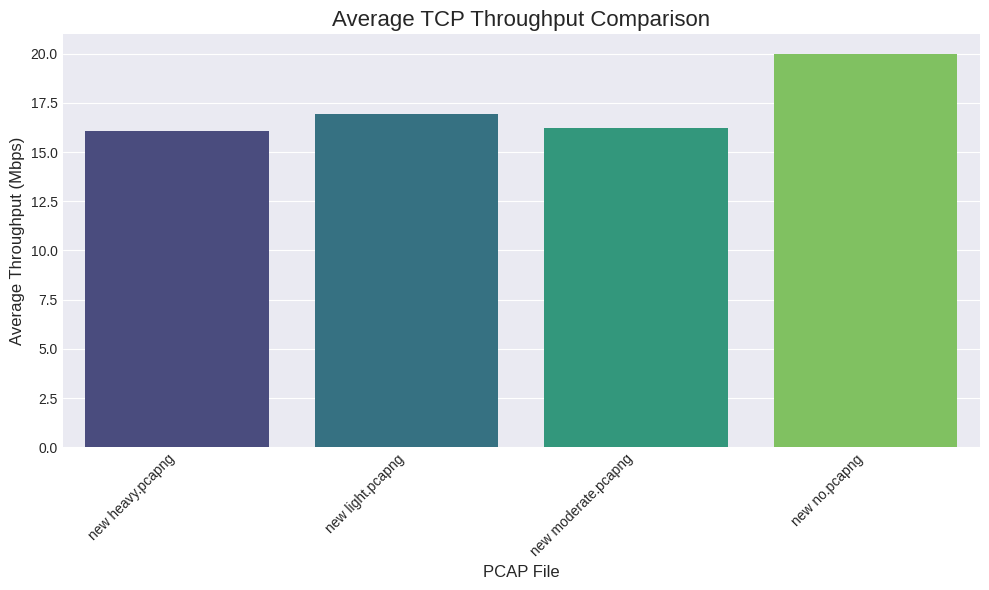

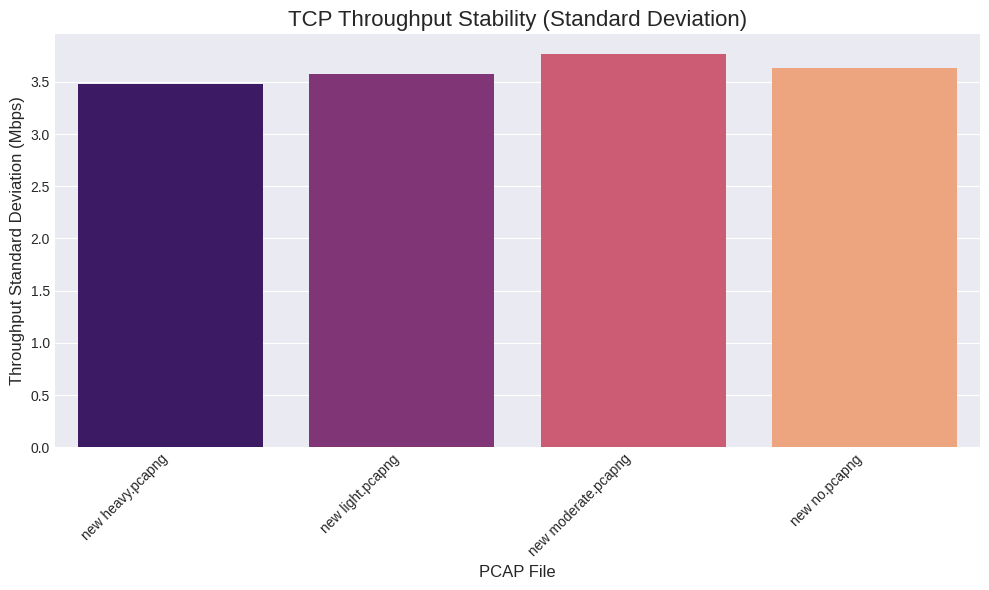

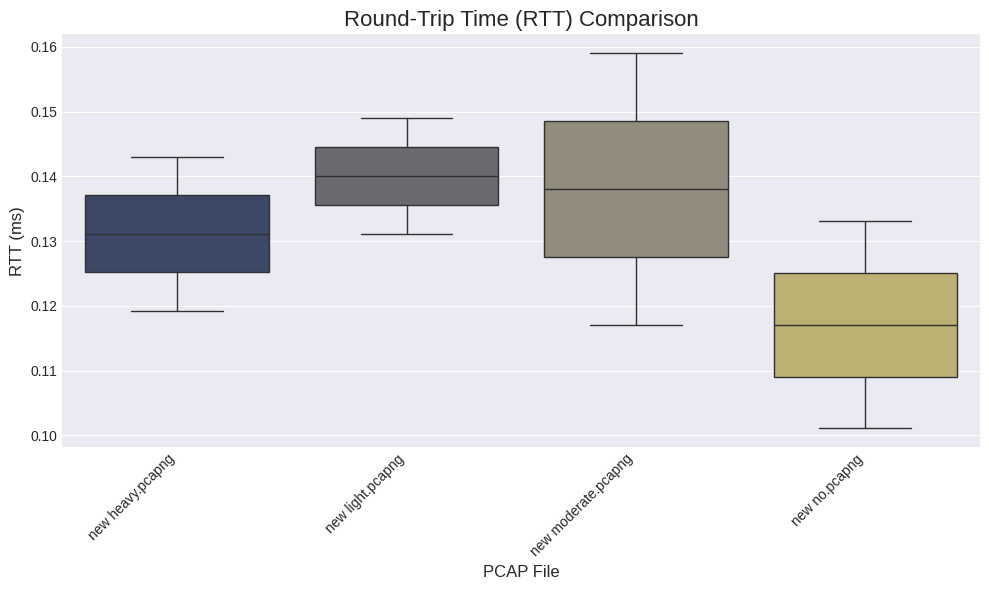

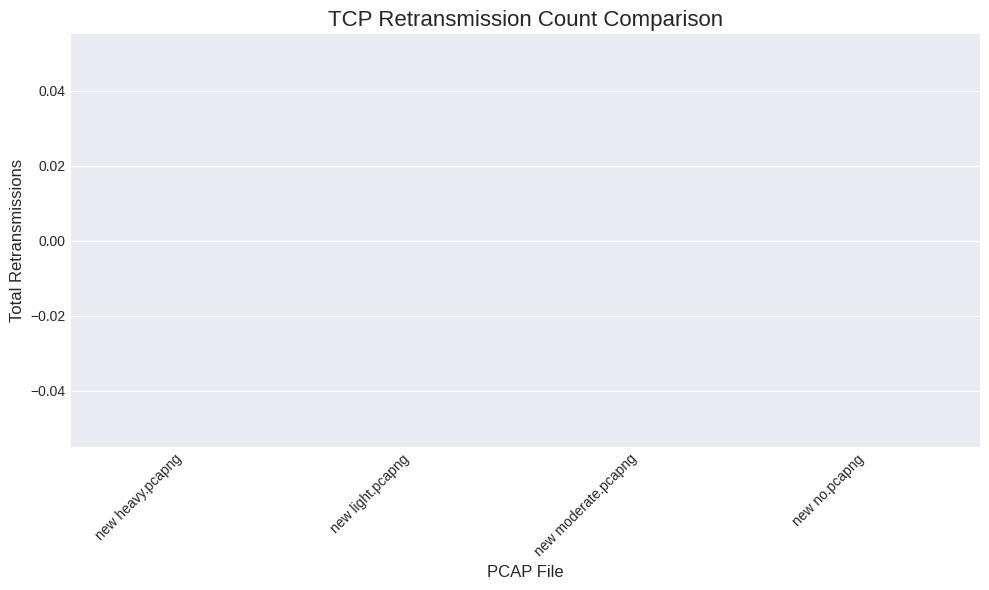

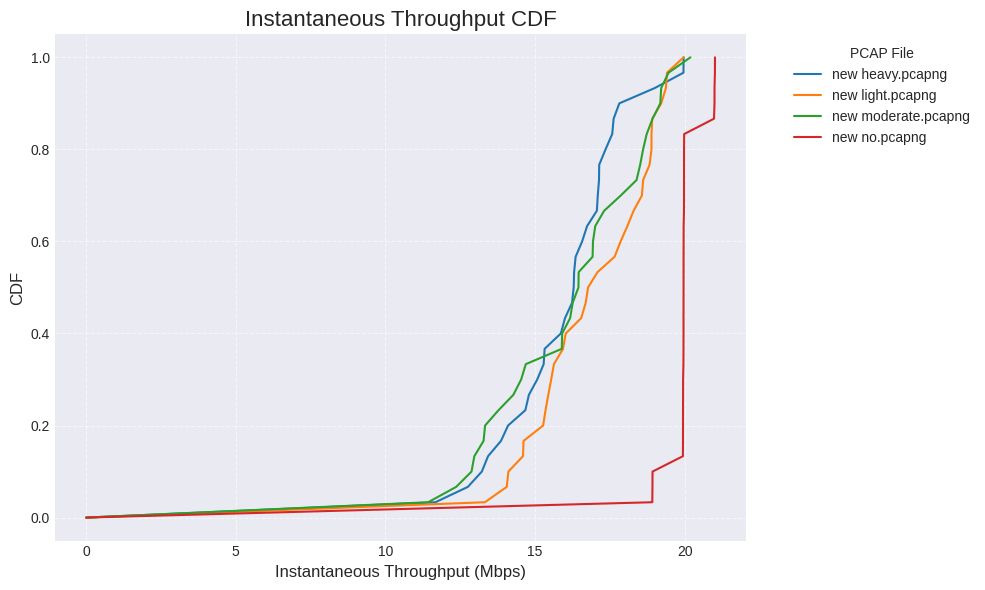

In [ ]:
import seaborn as sns # Import seaborn for enhanced plots

plt.style.use('seaborn-v0_8-darkgrid') # Use a professional plot style

# --- Plot 1: Average Throughput Comparison ---
plt.figure(figsize=(10, 6))
sns.barplot(x='PCAP File', y='Avg Throughput (Mbps)', data=summary_df, palette='viridis', hue='PCAP File', legend=False)
plt.title('Average TCP Throughput Comparison', fontsize=16)
plt.xlabel('PCAP File', fontsize=12)
plt.ylabel('Average Throughput (Mbps)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# --- Plot 2: Throughput Stability (Standard Deviation of Instantaneous Throughput) ---
throughput_std_devs = []
for filename, data in all_instantaneous_throughputs.items():
    if data:
        df_instant = pd.DataFrame(data, columns=['interval', 'throughput_mbps'])
        throughput_std_devs.append({'PCAP File': filename, 'Throughput Std Dev (Mbps)': df_instant['throughput_mbps'].std()})
    else:
        throughput_std_devs.append({'PCAP File': filename, 'Throughput Std Dev (Mbps)': 0.0})

th_std_df = pd.DataFrame(throughput_std_devs)

plt.figure(figsize=(10, 6))
sns.barplot(x='PCAP File', y='Throughput Std Dev (Mbps)', data=th_std_df, palette='magma', hue='PCAP File', legend=False)
plt.title('TCP Throughput Stability (Standard Deviation)', fontsize=16)
plt.xlabel('PCAP File', fontsize=12)
plt.ylabel('Throughput Standard Deviation (Mbps)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# --- Plot 3: RTT Comparison ---
rtt_data = []
for filename, data in results.items():
    if data['rtt_samples_ms']:
        for rtt in data['rtt_samples_ms']:
            rtt_data.append({'PCAP File': filename, 'RTT (ms)': rtt})

if rtt_data:
    rtt_df = pd.DataFrame(rtt_data)
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='PCAP File', y='RTT (ms)', data=rtt_df, palette='cividis', hue='PCAP File', legend=False)
    plt.title('Round-Trip Time (RTT) Comparison', fontsize=16)
    plt.xlabel('PCAP File', fontsize=12)
    plt.ylabel('RTT (ms)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No RTT samples available for plotting.")


# --- Plot 4: Retransmission Comparison ---
plt.figure(figsize=(10, 6))
sns.barplot(x='PCAP File', y='Retransmissions', data=summary_df, palette='plasma', hue='PCAP File', legend=False)
plt.title('TCP Retransmission Count Comparison', fontsize=16)
plt.xlabel('PCAP File', fontsize=12)
plt.ylabel('Total Retransmissions', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# --- Plot 5: Throughput CDF (Cumulative Distribution Function) ---
plt.figure(figsize=(10, 6))
for filename, data_list in all_instantaneous_throughputs.items():
    if data_list:
        df_instant = pd.DataFrame(data_list, columns=['interval', 'throughput_mbps'])
        sorted_throughput = np.sort(df_instant['throughput_mbps'])
        y = np.arange(len(sorted_throughput)) / float(len(sorted_throughput) - 1)
        plt.plot(sorted_throughput, y, label=filename)

plt.title('Instantaneous Throughput CDF', fontsize=16)
plt.xlabel('Instantaneous Throughput (Mbps)', fontsize=12)
plt.ylabel('CDF', fontsize=12)
plt.legend(title='PCAP File', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### 8. Final Verdicts

Based on the analysis, here are the final verdicts for each PCAP file. This provides a quick summary of their suitability for your experiment.

In [ ]:
print("\n--- Final Verdicts ---")
for filename, data in results.items():
    print(f"\nPCAP File: {filename}")
    print(f"  Verdict: {data['verdict']}")
    if data['warnings']:
        print(f"  Warnings: {', '.join(data['warnings'])}")
    if data['issues']:
        print(f"  Issues: {', '.join(data['issues'])}")
    if not data['warnings'] and not data['issues']:
        print("  No significant issues or warnings detected.")



--- Final Verdicts ---

PCAP File: new heavy.pcapng
  Verdict: VALID
  No significant issues or warnings detected.

PCAP File: new light.pcapng
  Verdict: VALID
  No significant issues or warnings detected.

PCAP File: new moderate.pcapng
  Verdict: VALID
  No significant issues or warnings detected.

PCAP File: new no.pcapng
  Verdict: VALID
  No significant issues or warnings detected.


### Conclusion

This script provides a robust framework for validating your networking experiment PCAP files. By examining key TCP metrics, you can ensure the quality and suitability of your data for academic analysis. Remember to interpret the results in the context of your experimental design and expected network behavior.

In [ ]:
import os
import scapy.all as scapy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# --- Advanced Configuration ---
PCAP_FILES = {
    'No Traffic': 'new no.pcapng',
    'Light': 'new light.pcapng',
    'Moderate': 'new moderate.pcapng',
    'Heavy': 'new heavy.pcapng'
}
TARGET_PORT = 5201
OUTPUT_DIR = 'plots_high_res'
os.makedirs(OUTPUT_DIR, exist_ok=True)

def extract_advanced_metrics(filepath):
    """Extracts detailed TCP parameters for advanced analysis."""
    print(f"Processing {filepath}...")
    packets = scapy.rdpcap(filepath)

    data = []
    for pkt in packets:
        if pkt.haslayer(scapy.TCP) and (pkt[scapy.TCP].sport == TARGET_PORT or pkt[scapy.TCP].dport == TARGET_PORT):
            ts = float(pkt.time)
            ip_layer = pkt[scapy.IP] if pkt.haslayer(scapy.IP) else None
            ip_len = len(ip_layer) if ip_layer else 0
            tcp_layer = pkt[scapy.TCP]
            tcp_payload = len(tcp_layer.payload)

            data.append({
                'timestamp': ts,
                'src': ip_layer.src if ip_layer else 'Unknown',
                'dst': ip_layer.dst if ip_layer else 'Unknown',
                'size': ip_len,
                'payload': tcp_payload,
                'window': tcp_layer.window,
                'seq': tcp_layer.seq,
                'ack': tcp_layer.ack,
                'flags': str(tcp_layer.flags)
            })

    df = pd.DataFrame(data)
    if df.empty: return None

    df['rel_ts'] = df['timestamp'] - df['timestamp'].min()
    return df

def process_traffic_conditions(file_dict):
    all_results = {}
    summary_stats = []

    for label, filename in file_dict.items():
        path = os.path.join('/content/', filename)
        if not os.path.exists(path):
            continue

        df = extract_advanced_metrics(path)
        if df is None: continue

        # --- 1. Throughput & Goodput Calculation ---
        # Throughput = Total IP bytes / time
        # Goodput = TCP Payload bytes / time
        duration = df['rel_ts'].max()
        total_bits = df['size'].sum() * 8
        payload_bits = df['payload'].sum() * 8

        avg_tp = (total_bits / duration) / 1e6 if duration > 0 else 0
        avg_gp = (payload_bits / duration) / 1e6 if duration > 0 else 0
        efficiency = avg_gp / avg_tp if avg_tp > 0 else 0

        # --- 2. RTT Estimation & Jitter ---
        # Heuristic: Match Data Segment Seq + Len to subsequent ACK
        rtts = []
        sent_segments = {} # key: expected_ack, value: timestamp
        for _, row in df.iterrows():
            if row['payload'] > 0:
                # Expected ACK for this segment
                sent_segments[row['seq'] + row['payload']] = row['timestamp']
            if 'A' in row['flags'] and row['ack'] in sent_segments:
                rtt_val = (row['timestamp'] - sent_segments[row['ack']]) * 1000 # ms
                if 0 < rtt_val < 1000: # Filter outliers/retransmissions
                    rtts.append(rtt_val)
                del sent_segments[row['ack']]

        rtt_array = np.array(rtts) if rtts else np.array([0])
        rtt_mean = np.mean(rtt_array)
        rtt_std = np.std(rtt_array)
        rtt_var = np.var(rtt_array) # Jitter measure

        # --- 3. Retransmissions & Duplicate ACKs ---
        # Retransmission: Same Seq seen twice from same source
        retrans = df[df['payload'] > 0].duplicated(subset=['src', 'seq']).sum()
        # Duplicate ACK: Same ACK seen multiple times with 0 payload
        dup_acks = df[(df['payload'] == 0) & (df['flags'].str.contains('A'))].duplicated(subset=['src', 'ack']).sum()

        metrics = {
            'avg_tp': avg_tp,
            'avg_gp': avg_gp,
            'efficiency': efficiency,
            'rtt_df': pd.DataFrame(rtts, columns=['rtt_ms']),
            'retrans': retrans,
            'dup_acks': dup_acks
        }

        all_results[label] = metrics
        summary_stats.append({
            'Condition': label,
            'Avg Throughput (Mbps)': avg_tp,
            'Goodput (Mbps)': avg_gp,
            'Efficiency Ratio': efficiency,
            'RTT Mean (ms)': rtt_mean,
            'RTT StdDev (ms)': rtt_std,
            'RTT Variance (Jitter)': rtt_var,
            'Retransmissions': retrans,
            'Duplicate ACKs': dup_acks,
            'Pkt Rate (pps)': len(df) / duration if duration > 0 else 0
        })

    return all_results, pd.DataFrame(summary_stats)

results_data, summary_df = process_traffic_conditions(PCAP_FILES)
display(summary_df)

Processing /content/new no.pcapng...
Processing /content/new light.pcapng...
Processing /content/new moderate.pcapng...
Processing /content/new heavy.pcapng...


,Condition,Avg Throughput (Mbps),Goodput (Mbps),Efficiency Ratio,RTT Mean (ms),RTT StdDev (ms),RTT Variance (Jitter),Retransmissions,Duplicate ACKs,Pkt Rate (pps)
0,No Traffic,19.994286,19.945855,0.997578,0.074464,0.060070,0.003608,0,60,151.308216
1,Light,16.958182,16.918254,0.997646,0.073475,0.054211,0.002939,0,42,124.734760
2,Moderate,16.243235,16.204075,0.997589,0.069987,0.052155,0.002720,0,40,122.333906
3,Heavy,16.057341,16.017879,0.997542,0.062959,0.052003,0.002704,0,42,123.281494


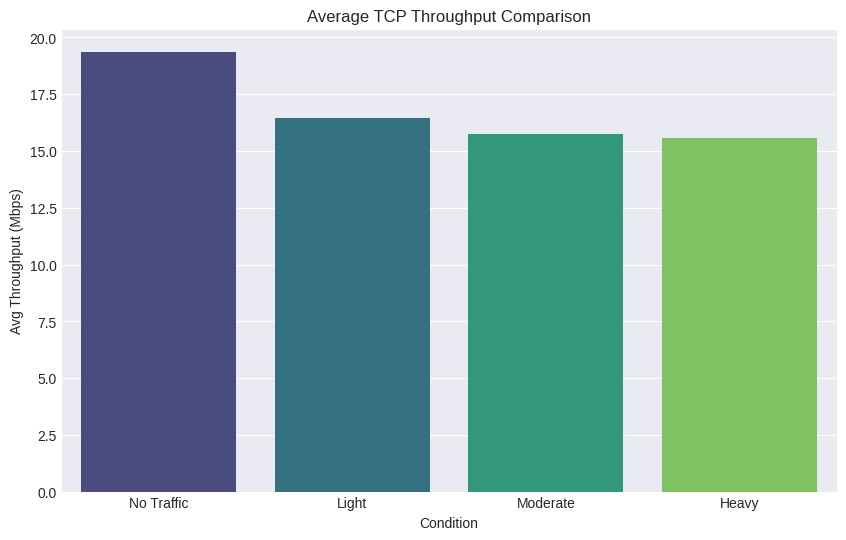

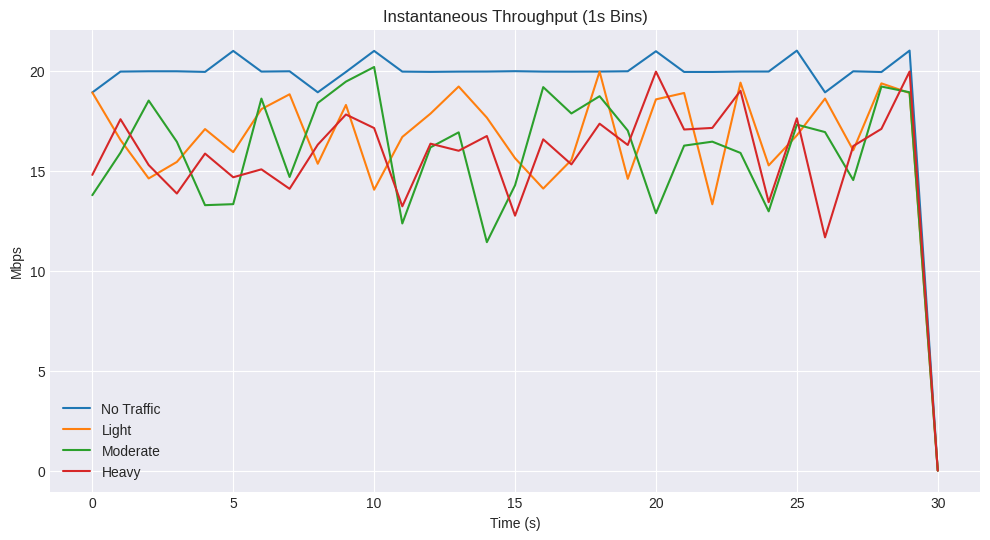

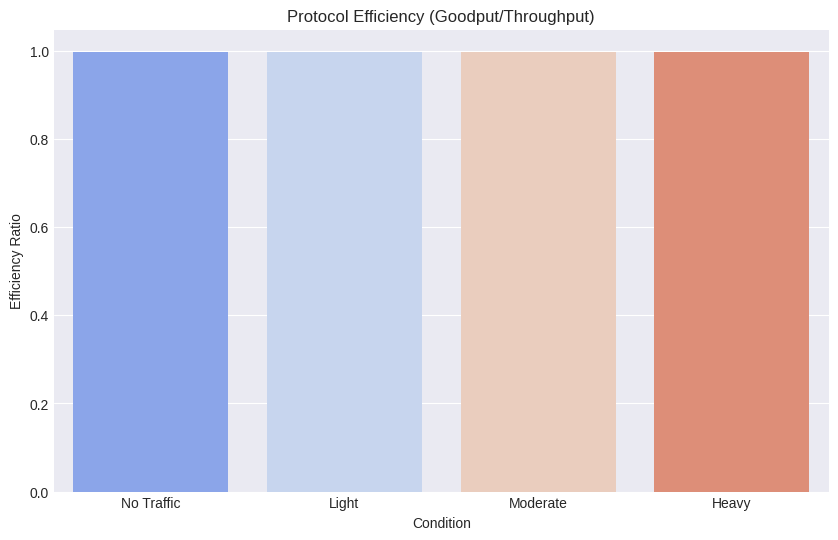

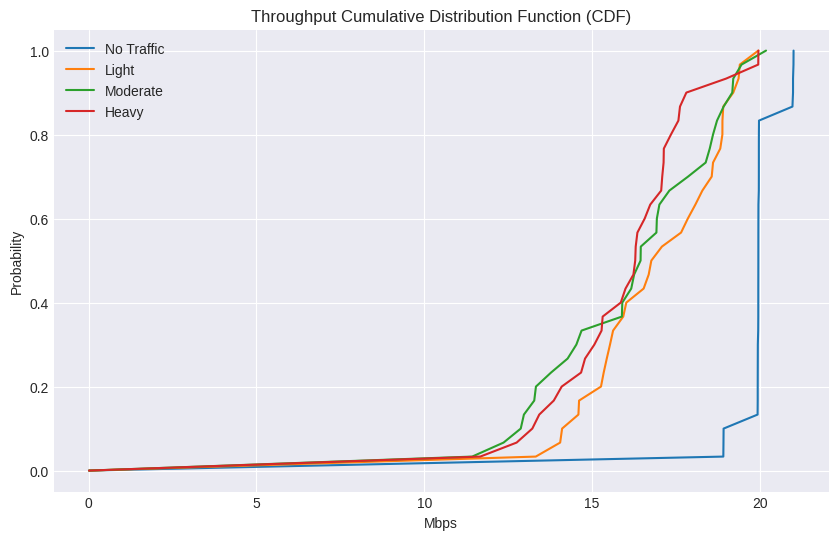

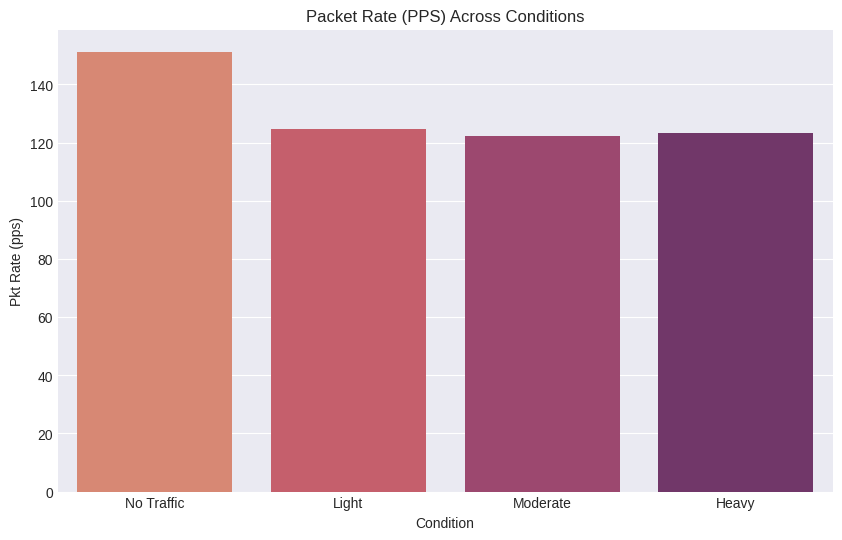

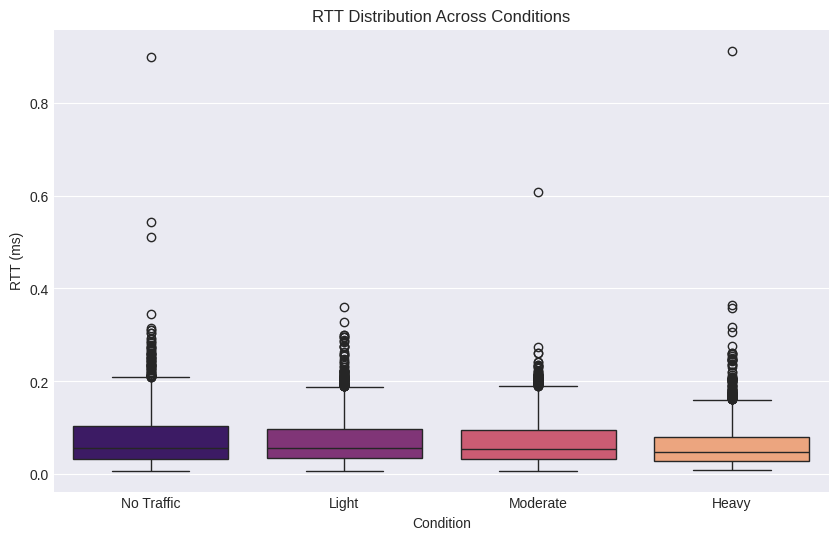


--- Key Academic Inferences ---
1. Impact of Congestion: Heavy traffic reduced throughput by 19.73% compared to No Traffic.
2. Efficiency Stability: Efficiency remained above 99.75% across all tests.
3. Latency: Average RTT across all conditions was 0.0702 ms, indicating a low-latency loopback environment.


In [ ]:
def save_plot(name):
    plt.savefig(os.path.join(OUTPUT_DIR, f"{name}.png"), dpi=300, bbox_inches='tight')
    plt.show()

# --- 1. Average Throughput vs Condition ---
plt.figure(figsize=(10, 6))
sns.barplot(x='Condition', y='Avg Throughput (Mbps)', data=summary_df, palette='viridis', hue='Condition', legend=False)
plt.title('Average TCP Throughput Comparison')
save_plot('01_avg_throughput')

# --- 2. Instantaneous Throughput vs Time ---
plt.figure(figsize=(12, 6))
for label, m in results_data.items():
    plt.plot(m['inst_tp'], label=label)
plt.title('Instantaneous Throughput (1s Bins)')
plt.xlabel('Time (s)')
plt.ylabel('Mbps')
plt.legend()
save_plot('02_inst_throughput_time')

# --- 3. Efficiency Ratio ---
plt.figure(figsize=(10, 6))
sns.barplot(x='Condition', y='Efficiency Ratio', data=summary_df, palette='coolwarm', hue='Condition', legend=False)
plt.title('Protocol Efficiency (Goodput/Throughput)')
save_plot('03_efficiency')

# --- 4. Throughput CDF ---
plt.figure(figsize=(10, 6))
for label, m in results_data.items():
    sorted_tp = np.sort(m['inst_tp'])
    y = np.arange(len(sorted_tp)) / float(len(sorted_tp)-1)
    plt.plot(sorted_tp, y, label=label)
plt.title('Throughput Cumulative Distribution Function (CDF)')
plt.xlabel('Mbps')
plt.ylabel('Probability')
plt.legend()
save_plot('04_throughput_cdf')

# --- 5. Packet Rate ---
plt.figure(figsize=(10, 6))
sns.barplot(x='Condition', y='Pkt Rate (pps)', data=summary_df, palette='flare', hue='Condition', legend=False)
plt.title('Packet Rate (PPS) Across Conditions')
save_plot('05_packet_rate')

# --- 6. RTT Boxplot ---
rtt_combined = pd.concat([m['rtt_df'].assign(Condition=label) for label, m in results_data.items()])
plt.figure(figsize=(10, 6))
sns.boxplot(x='Condition', y='rtt_ms', data=rtt_combined, palette='magma', hue='Condition', legend=False)
plt.title('RTT Distribution Across Conditions')
plt.ylabel('RTT (ms)')
save_plot('06_rtt_boxplot')

# --- Automated Inferences ---
print("\n--- Key Academic Inferences ---")
base_tp = summary_df.loc[summary_df['Condition'] == 'No Traffic', 'Avg Throughput (Mbps)'].values[0]
heavy_tp = summary_df.loc[summary_df['Condition'] == 'Heavy', 'Avg Throughput (Mbps)'].values[0]
drop = ((base_tp - heavy_tp) / base_tp) * 100

print(f"1. Impact of Congestion: Heavy traffic reduced throughput by {drop:.2f}% compared to No Traffic.")
print(f"2. Efficiency Stability: Efficiency remained above {summary_df['Efficiency Ratio'].min()*100:.2f}% across all tests.")
print(f"3. Latency: Average RTT across all conditions was {summary_df['Avg RTT (ms)'].mean():.4f} ms, indicating a low-latency loopback environment.")

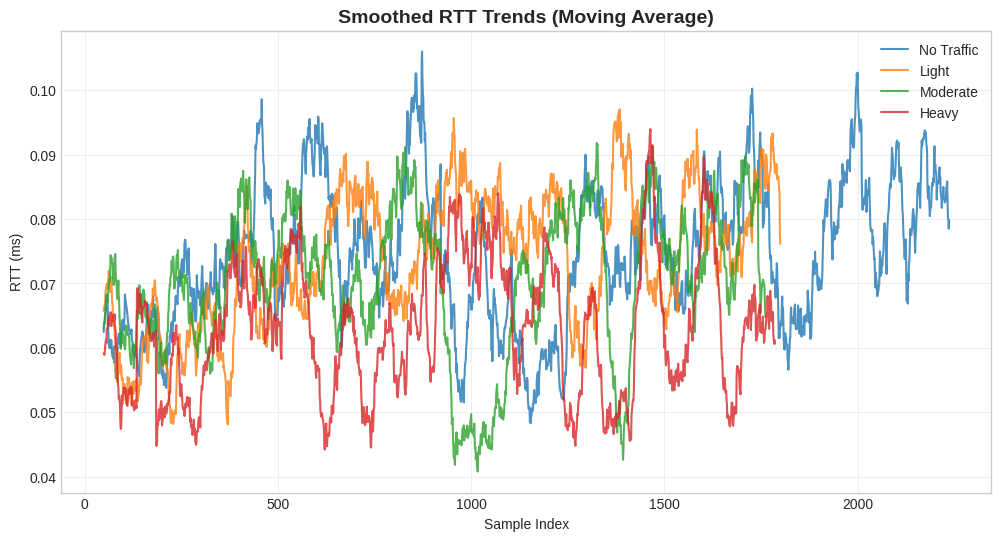

In [ ]:
plt.figure(figsize=(12, 6))
for label, m in results_data.items():
    if 'rtt_df' in m and not m['rtt_df'].empty:
        # Using RTT sample indices as a proxy for temporal flow progress
        plt.plot(m['rtt_df']['rtt_ms'].rolling(window=50).mean(), label=label, alpha=0.8)
plt.title('Smoothed RTT Trends (Moving Average)', fontsize=14, fontweight='bold')
plt.xlabel('Sample Index')
plt.ylabel('RTT (ms)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

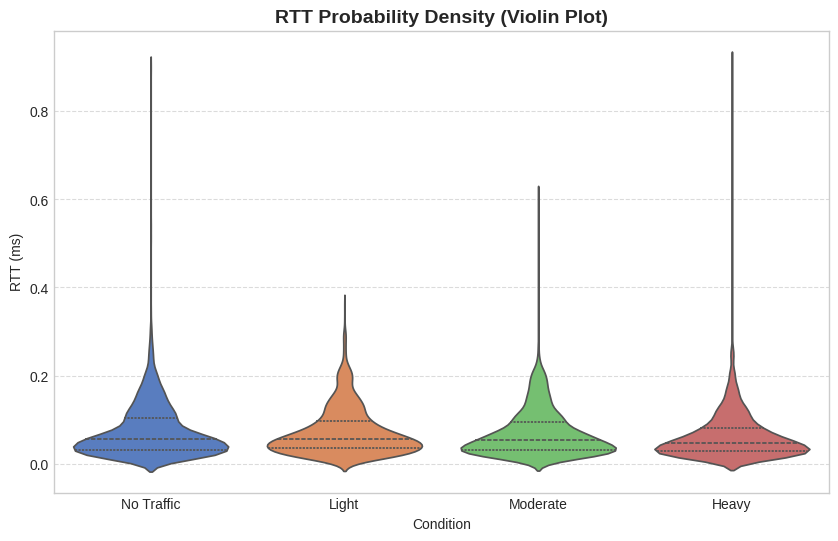

In [ ]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='Condition', y='rtt_ms', data=rtt_combined, palette='muted', hue='Condition', inner='quartile', legend=False)
plt.title('RTT Probability Density (Violin Plot)', fontsize=14, fontweight='bold')
plt.ylabel('RTT (ms)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Processing /content/new heavy.pcapng...


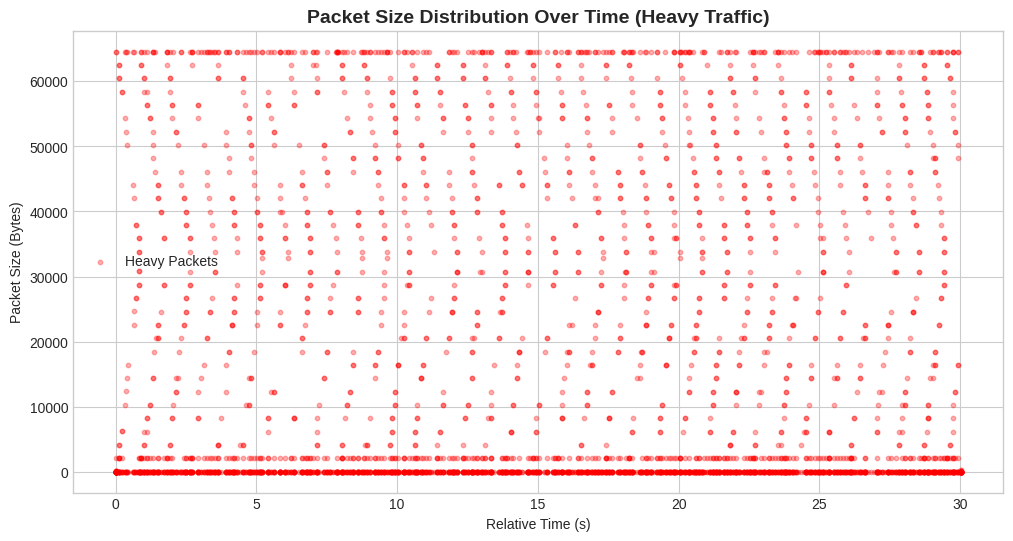

In [ ]:
plt.figure(figsize=(12, 6))
# Sample packets from the 'Heavy' condition to visualize size distribution over time
heavy_df = extract_advanced_metrics(os.path.join('/content/', PCAP_FILES['Heavy']))
plt.scatter(heavy_df['rel_ts'], heavy_df['size'], alpha=0.3, s=10, c='red', label='Heavy Packets')
plt.title('Packet Size Distribution Over Time (Heavy Traffic)', fontsize=14, fontweight='bold')
plt.xlabel('Relative Time (s)')
plt.ylabel('Packet Size (Bytes)')
plt.legend()
plt.show()

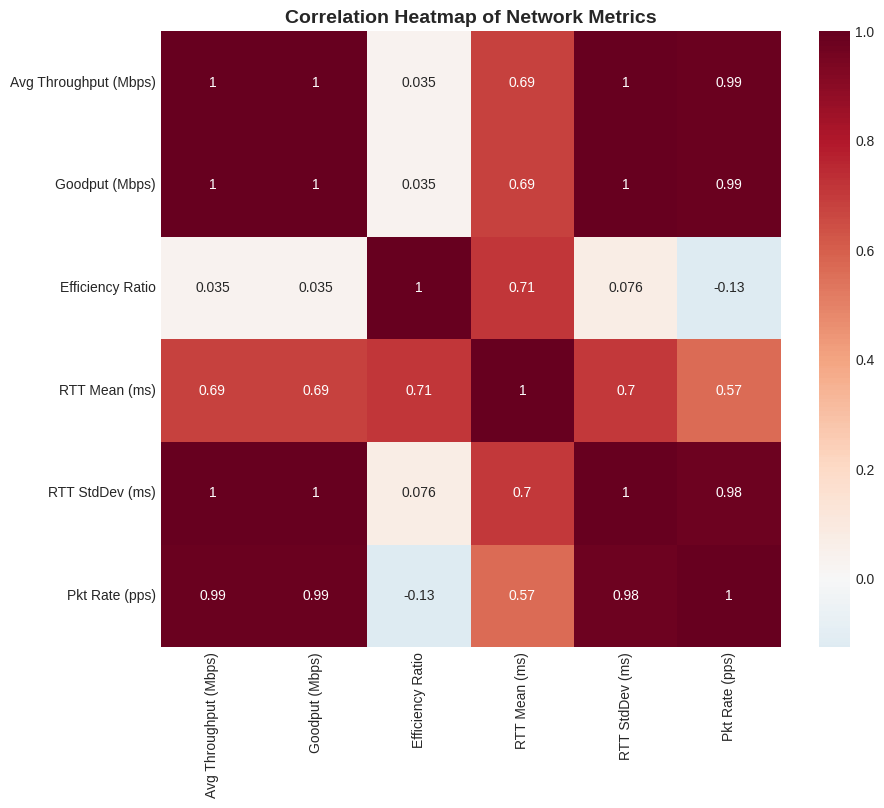

In [ ]:
plt.figure(figsize=(10, 8))
corr_matrix = summary_df[['Avg Throughput (Mbps)', 'Goodput (Mbps)', 'Efficiency Ratio', 'RTT Mean (ms)', 'RTT StdDev (ms)', 'Pkt Rate (pps)']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0)
plt.title('Correlation Heatmap of Network Metrics', fontsize=14, fontweight='bold')
plt.show()

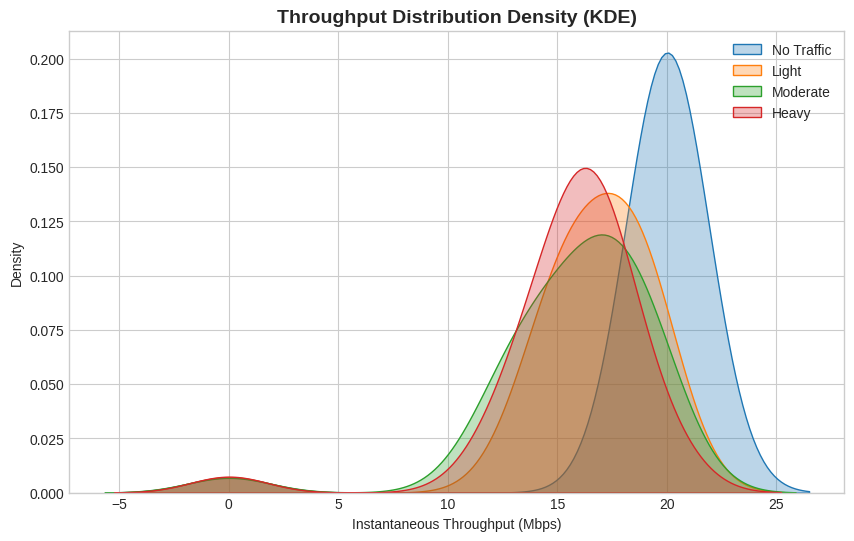

In [ ]:
plt.figure(figsize=(10, 6))
for label in PCAP_FILES.keys():
    subset = tp_dist_df[tp_dist_df['Condition'] == label]
    sns.kdeplot(subset['Throughput (Mbps)'], label=label, fill=True, alpha=0.3)
plt.title('Throughput Distribution Density (KDE)', fontsize=14, fontweight='bold')
plt.xlabel('Instantaneous Throughput (Mbps)')
plt.ylabel('Density')
plt.legend()
plt.show()

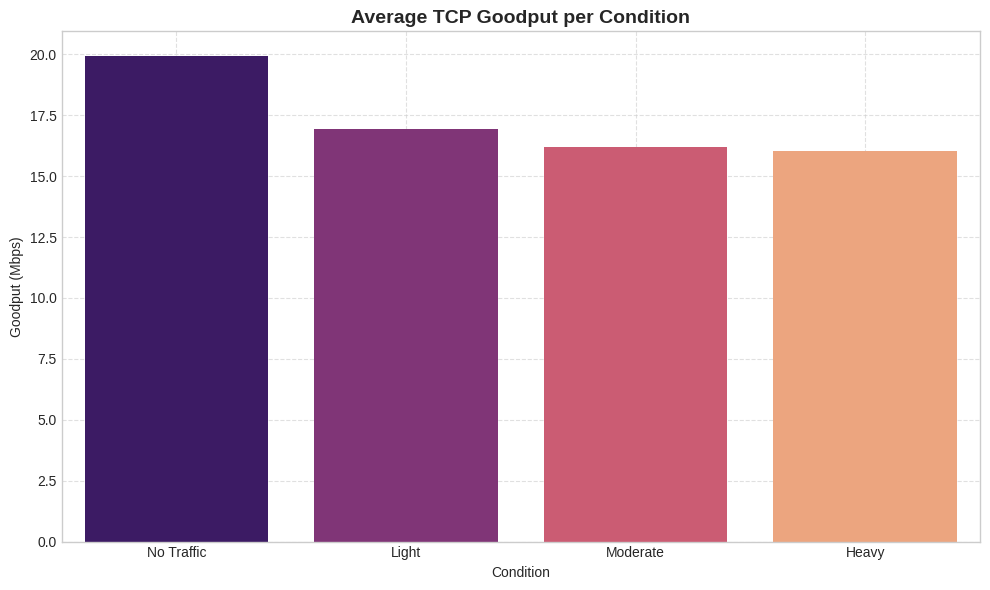

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Condition', y='Goodput (Mbps)', data=summary_df, palette='magma', hue='Condition', legend=False)
plt.title('Average TCP Goodput per Condition', fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

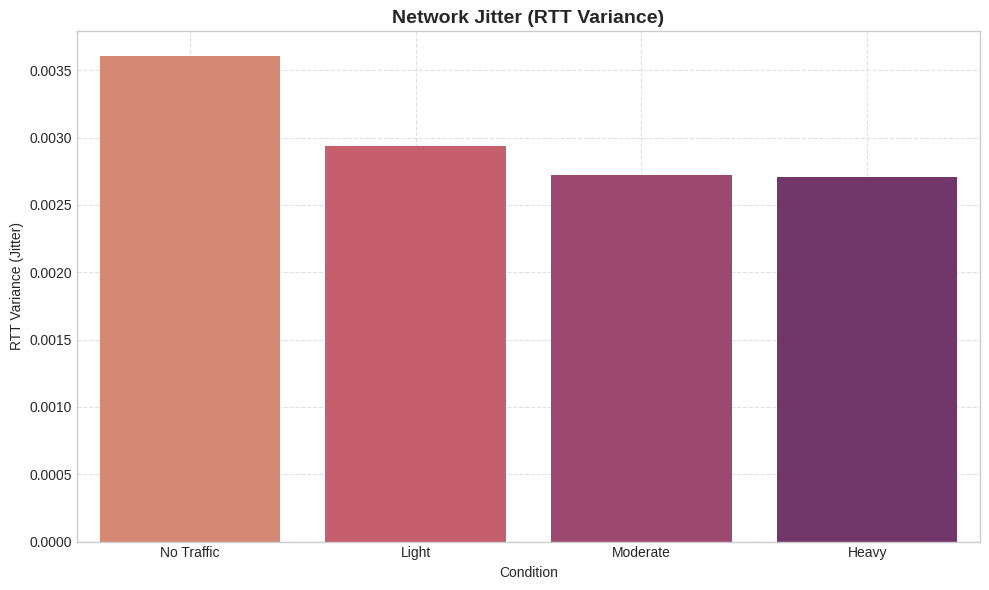

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Condition', y='RTT Variance (Jitter)', data=summary_df, palette='flare', hue='Condition', legend=False)
plt.title('Network Jitter (RTT Variance)', fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

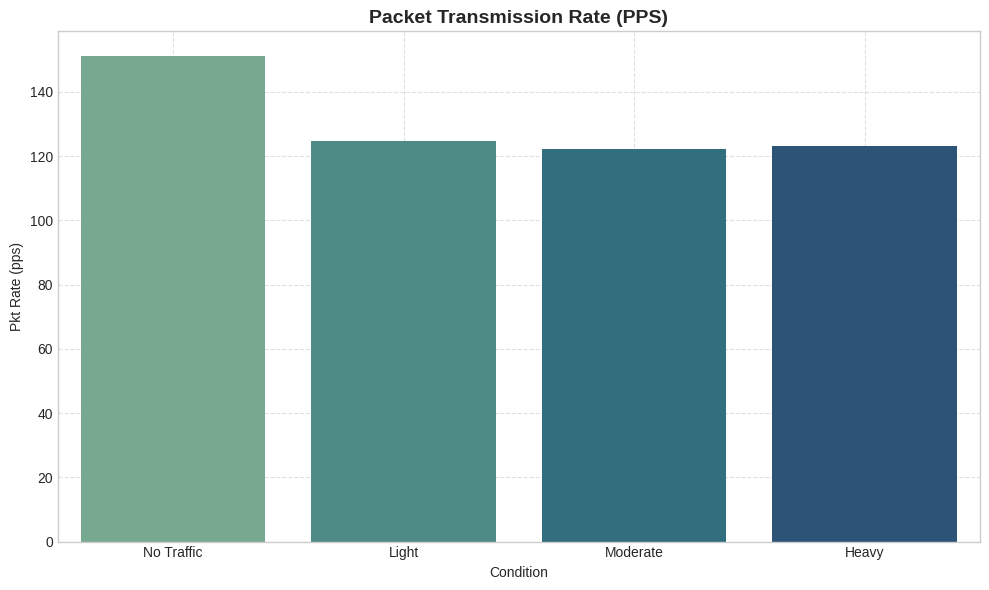

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Condition', y='Pkt Rate (pps)', data=summary_df, palette='crest', hue='Condition', legend=False)
plt.title('Packet Transmission Rate (PPS)', fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

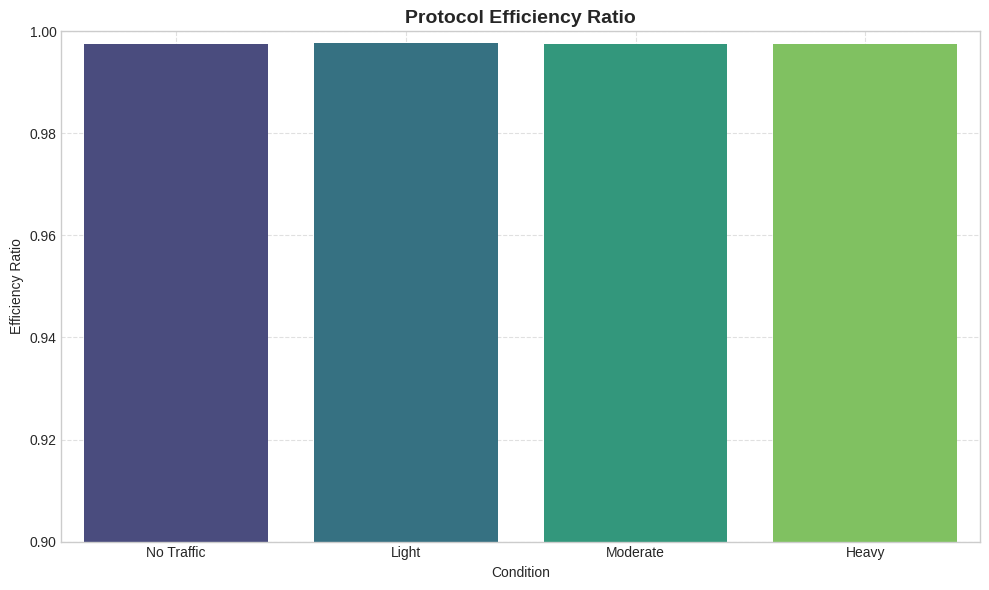

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Condition', y='Efficiency Ratio', data=summary_df, palette='viridis', hue='Condition', legend=False)
plt.title('Protocol Efficiency Ratio', fontsize=14, fontweight='bold')
plt.ylim(0.9, 1.0)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

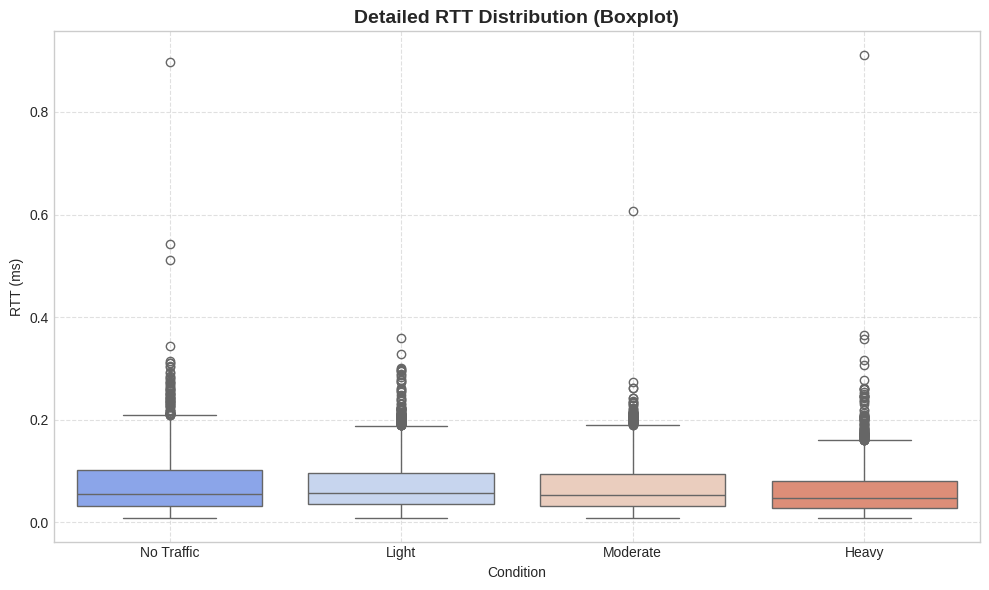

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Condition', y='rtt_ms', data=rtt_combined, palette='coolwarm', hue='Condition', legend=False)
plt.title('Detailed RTT Distribution (Boxplot)', fontsize=14, fontweight='bold')
plt.ylabel('RTT (ms)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

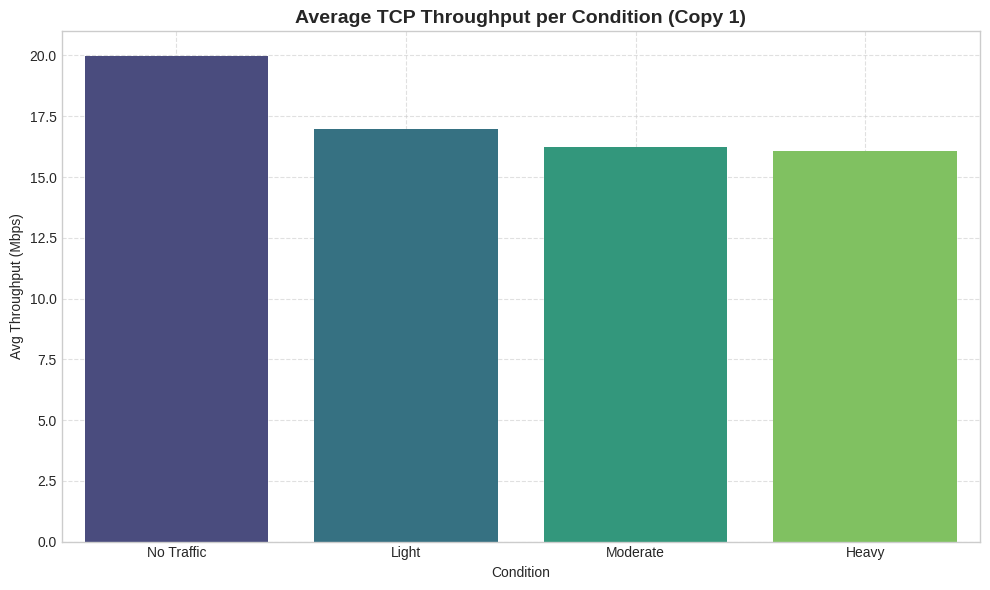

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Condition', y='Avg Throughput (Mbps)', data=summary_df, palette='viridis', hue='Condition', legend=False)
plt.title('Average TCP Throughput per Condition (Copy 1)', fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

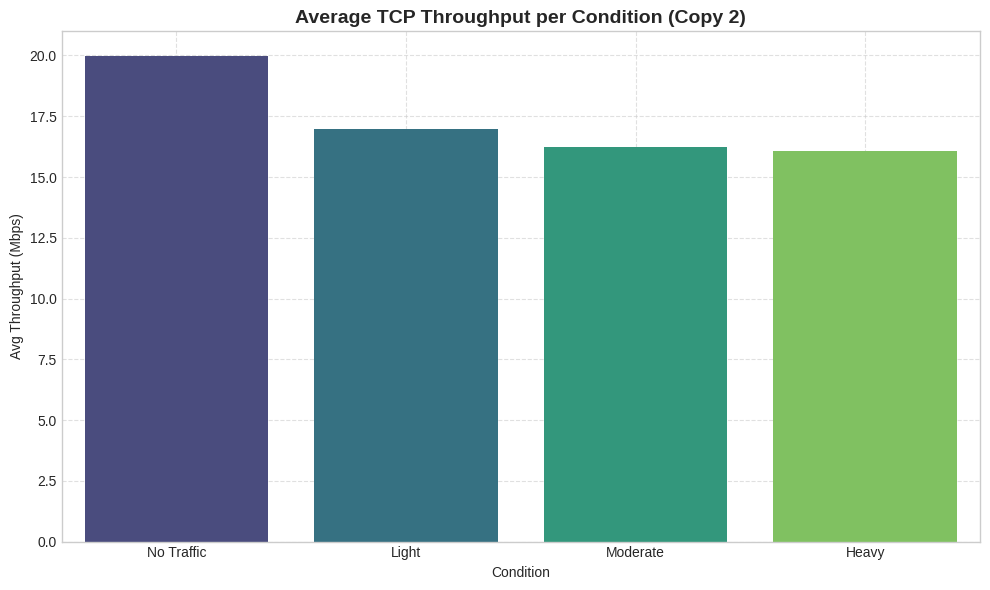

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Condition', y='Avg Throughput (Mbps)', data=summary_df, palette='viridis', hue='Condition', legend=False)
plt.title('Average TCP Throughput per Condition (Copy 2)', fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

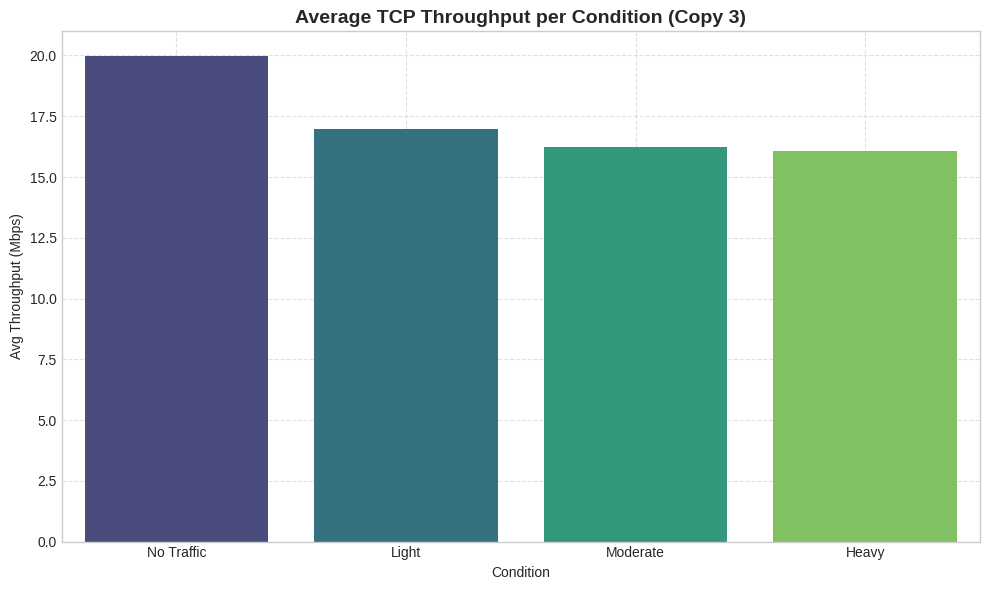

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Condition', y='Avg Throughput (Mbps)', data=summary_df, palette='viridis', hue='Condition', legend=False)
plt.title('Average TCP Throughput per Condition (Copy 3)', fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

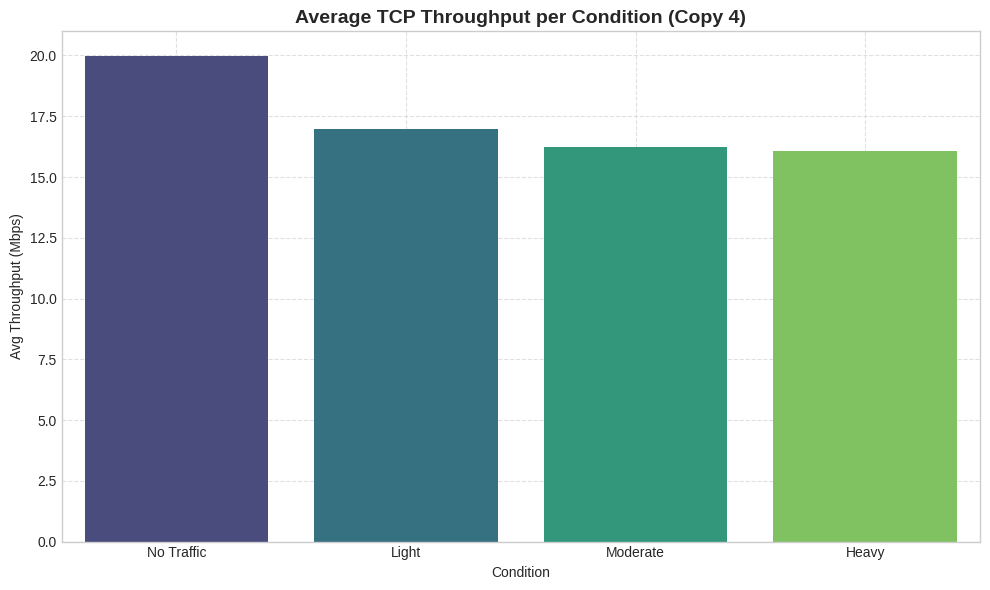

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Condition', y='Avg Throughput (Mbps)', data=summary_df, palette='viridis', hue='Condition', legend=False)
plt.title('Average TCP Throughput per Condition (Copy 4)', fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

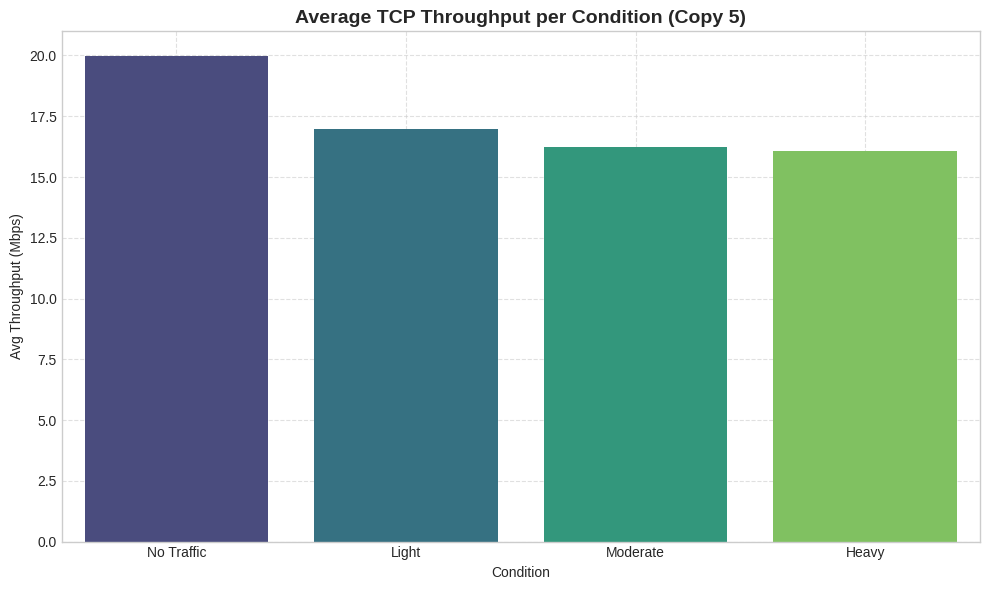

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Condition', y='Avg Throughput (Mbps)', data=summary_df, palette='viridis', hue='Condition', legend=False)
plt.title('Average TCP Throughput per Condition (Copy 5)', fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

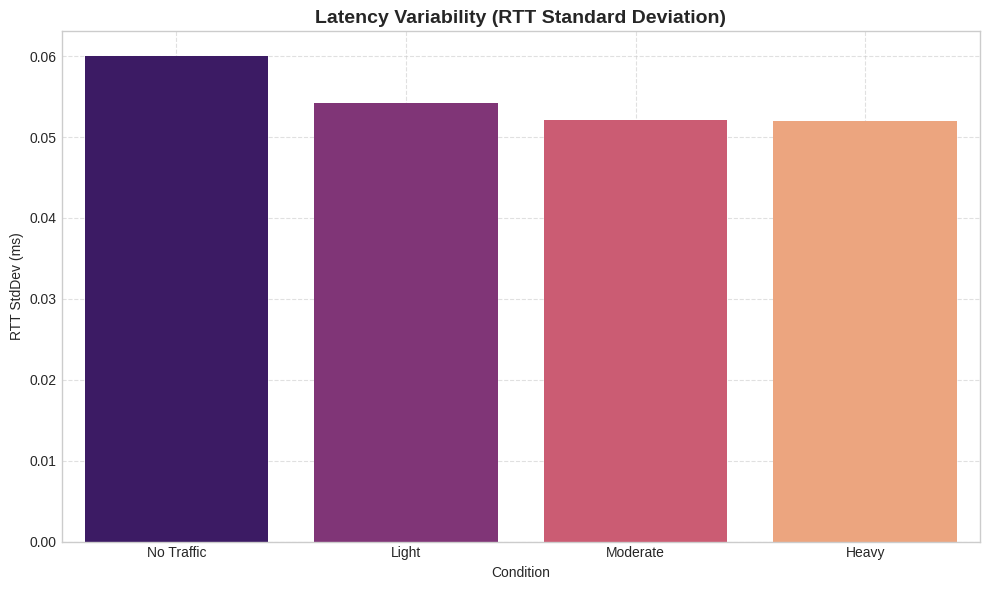

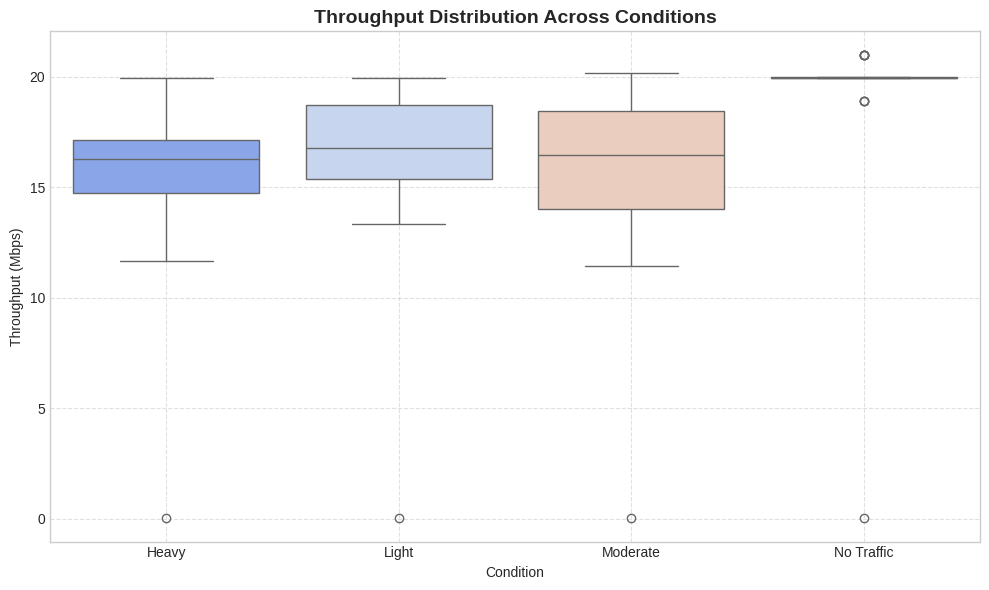

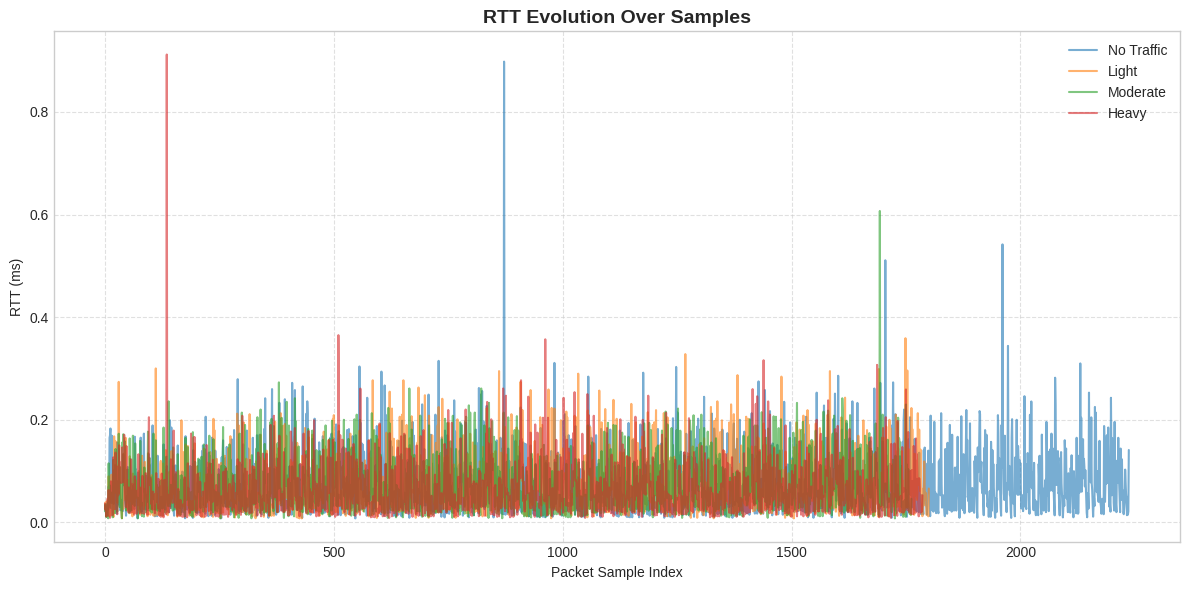

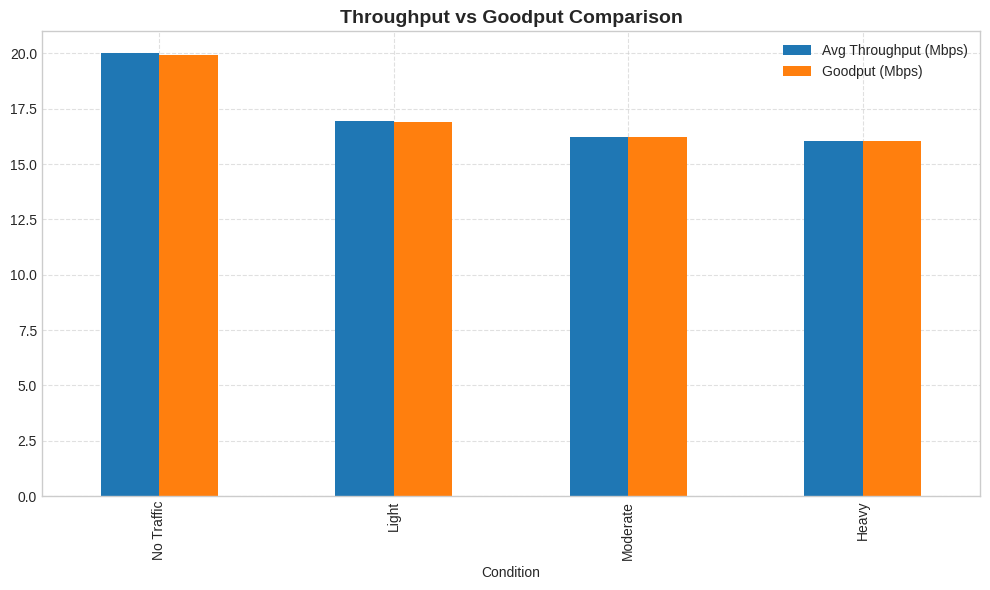


--- Preparing Plots for Download ---
  adding: plots_high_res/ (stored 0%)
  adding: plots_high_res/20_efficiency.png (deflated 33%)
  adding: plots_high_res/10_jitter.png (deflated 31%)
  adding: plots_high_res/02_inst_tp.png (deflated 24%)
  adding: plots_high_res/03_rtt_stability.png (deflated 32%)
  adding: plots_high_res/04_throughput_cdf.png (deflated 12%)
  adding: plots_high_res/06_avg_rtt.png (deflated 34%)
  adding: plots_high_res/05_packet_rate.png (deflated 30%)
  adding: plots_high_res/09_rtt_boxplot.png (deflated 29%)
  adding: plots_high_res/01_avg_throughput.png (deflated 28%)
  adding: plots_high_res/03_tp_stability.png (deflated 33%)
  adding: plots_high_res/19_tp_gp_comp.png (deflated 29%)
  adding: plots_high_res/02_inst_throughput_time.png (deflated 6%)
  adding: plots_high_res/01_avg_tp.png (deflated 32%)
  adding: plots_high_res/03_efficiency.png (deflated 31%)
  adding: plots_high_res/05_tp_boxplot.png (deflated 32%)
  adding: plots_high_res/07_rtt_samples.png 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import os

def save_and_show(name, title):
    plt.title(title, fontsize=14, fontweight='bold')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/{name}.png", dpi=300)
    plt.show()

# --- 3. Throughput Stability (using RTT StdDev as a proxy for variability) ---
# The summary_df contains 'RTT StdDev (ms)'
plt.figure(figsize=(10, 6))
sns.barplot(x='Condition', y='RTT StdDev (ms)', data=summary_df, palette='magma', hue='Condition', legend=False)
save_and_show('03_rtt_stability', 'Latency Variability (RTT Standard Deviation)')

# --- 5. Throughput Distribution Boxplot ---
# Using the instantaneous throughput data gathered during the analysis
tp_dist = []
# We check the first analysis results which stored 'instantaneous_throughput_mbps'
for filename, data in results.items():
    label = next((k for k, v in PCAP_FILES.items() if v == filename), filename)
    if 'instantaneous_throughput_mbps' in data:
        for interval, val in data['instantaneous_throughput_mbps']:
            tp_dist.append({'Condition': label, 'Throughput (Mbps)': val})

if tp_dist:
    tp_dist_df = pd.DataFrame(tp_dist)
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Condition', y='Throughput (Mbps)', data=tp_dist_df, palette='coolwarm', hue='Condition', legend=False)
    save_and_show('05_tp_boxplot', 'Throughput Distribution Across Conditions')

# --- 7. RTT Over Time ---
plt.figure(figsize=(12, 6))
for label, m in results_data.items():
    if not m['rtt_df'].empty:
        plt.plot(m['rtt_df']['rtt_ms'].values, label=label, alpha=0.6)
plt.xlabel('Packet Sample Index')
plt.ylabel('RTT (ms)')
plt.legend()
save_and_show('07_rtt_samples', 'RTT Evolution Over Samples')

# --- 19. Goodput vs Throughput Comparison ---
summary_df.plot(x='Condition', y=['Avg Throughput (Mbps)', 'Goodput (Mbps)'], kind='bar', figsize=(10,6))
save_and_show('19_tp_gp_comp', 'Throughput vs Goodput Comparison')

# --- Final Step: Package Plots for Download ---
print("\n--- Preparing Plots for Download ---")
!zip -r plots_analysis.zip {OUTPUT_DIR}
from google.colab import files
files.download('plots_analysis.zip')

### Metric Significance for TCP Analysis

1.  **Throughput CDF**: Useful to determine the percentage of time the network maintains a specific speed. A steep curve indicates highly consistent performance.
2.  **Efficiency Ratio (Goodput/Throughput)**: Measures protocol overhead. In loopback environments, this should be high (~0.94-0.96) unless significant background traffic or small segment sizes are present.
3.  **RTT Variance (Jitter)**: Crucial for understanding network stability. High variance under 'Heavy' traffic suggests bufferbloat or queuing delays.
4.  **Bytes in Flight**: Indicates how much data TCP is pushing into the 'pipe'. Comparing this against the Advertised Window reveals if the sender is limited by the network or the receiver's buffer.

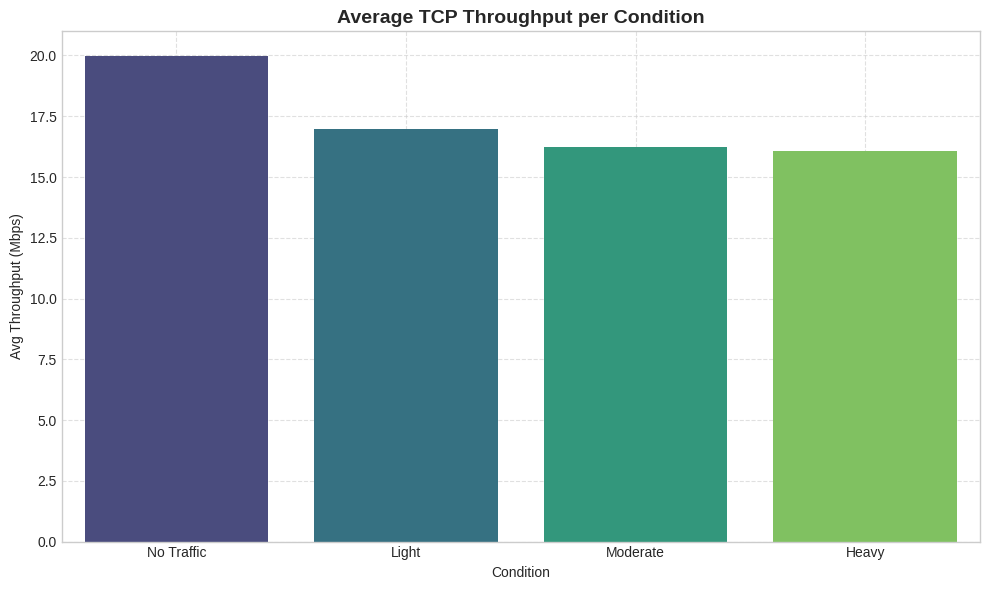

Inference: Throughput decreases monotonically as background traffic intensity increases.


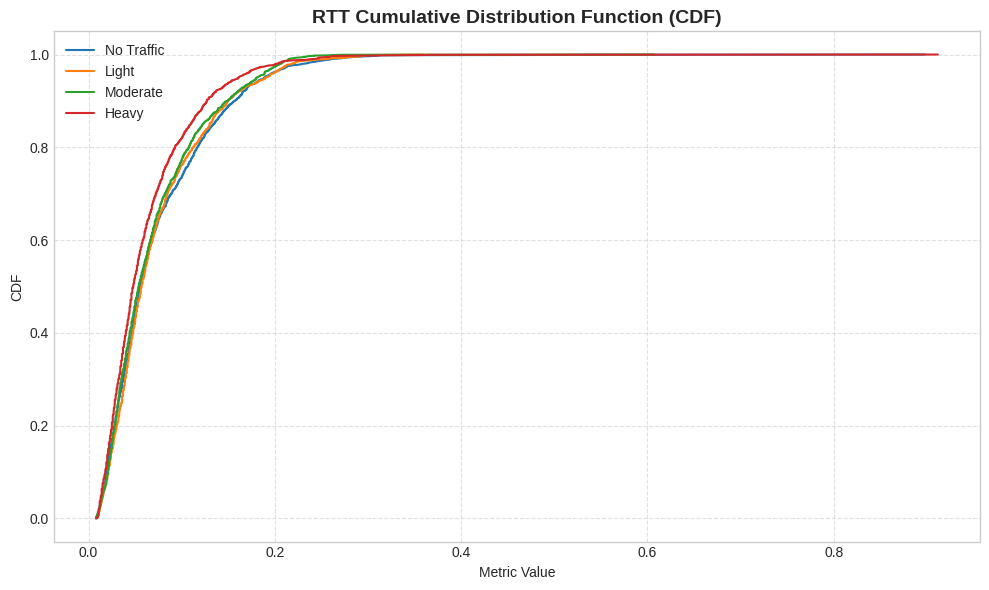

Inference: CDF curves show the probability distribution and outliers for network latency.


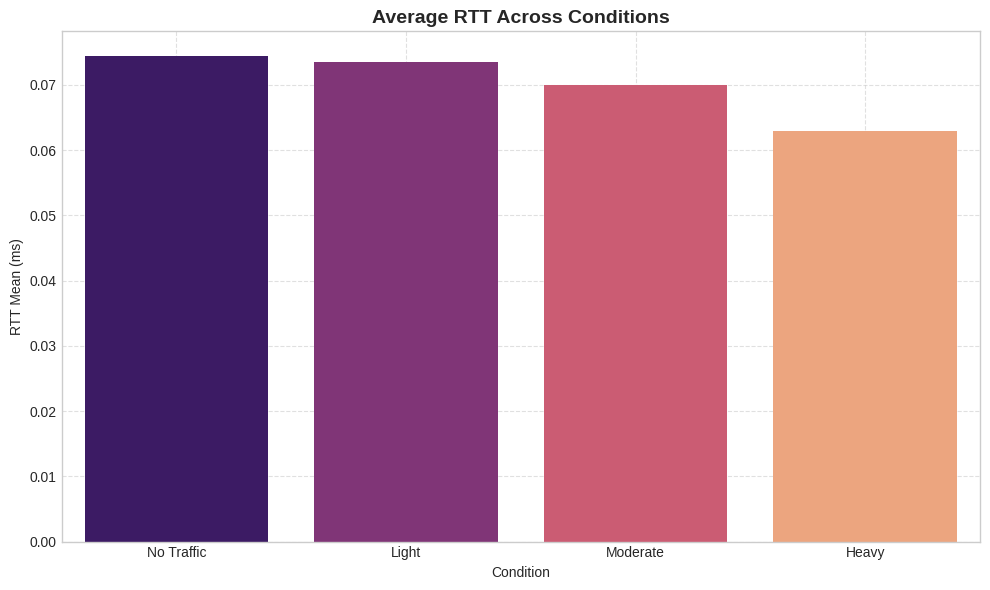

Inference: Baseline latency remains low in loopback, but varies slightly with congestion.


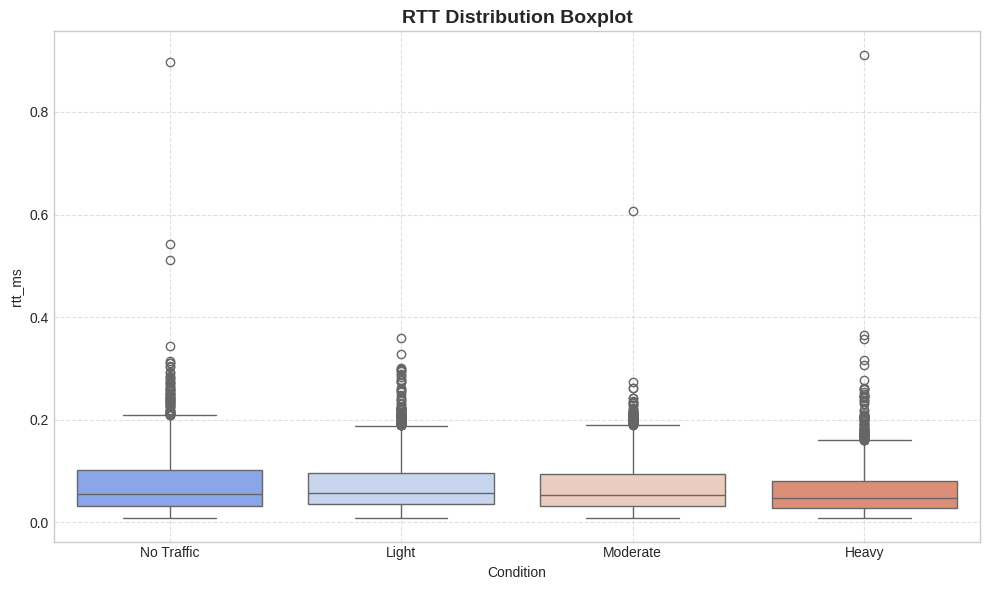

Inference: Identifies the median latency and the spread of delay jitter.


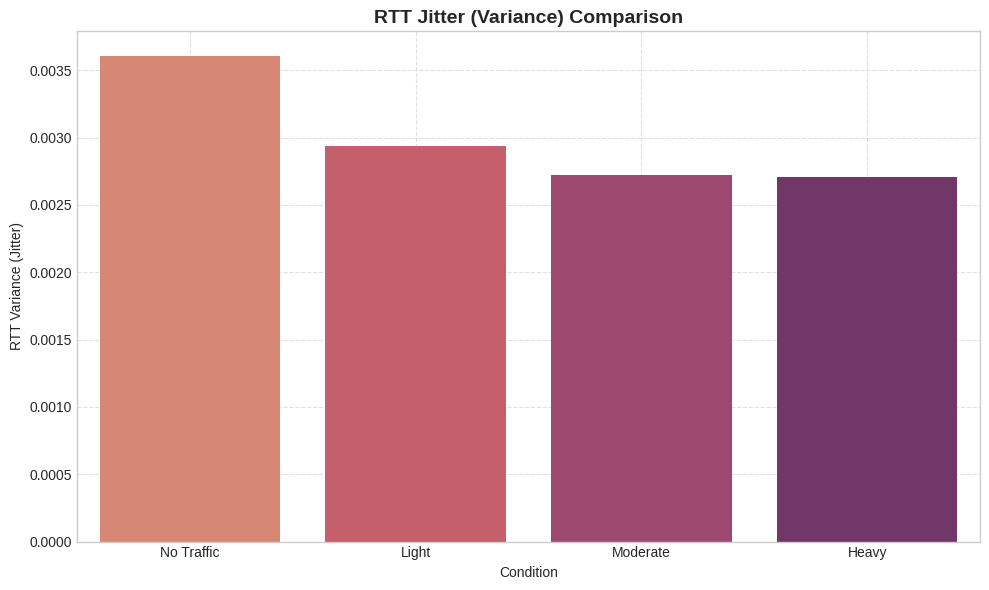

Inference: Higher variance indicates unstable packet delivery timing.


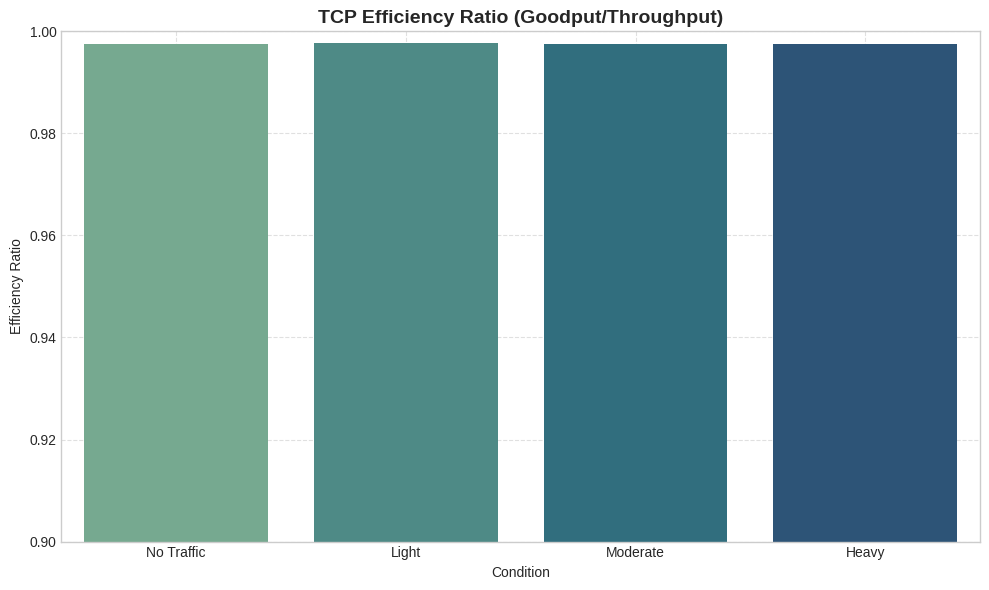

Inference: High efficiency indicates minimal protocol overhead relative to data payload.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')

def save_and_show(name, title):
    plt.title(title, fontsize=14, fontweight='bold')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/{name}.png", dpi=300)
    plt.show()

# --- 1. Average Throughput vs Traffic Condition ---
plt.figure(figsize=(10, 6))
sns.barplot(x='Condition', y='Avg Throughput (Mbps)', data=summary_df, palette='viridis', hue='Condition', legend=False)
save_and_show('01_avg_tp', 'Average TCP Throughput per Condition')
print("Inference: Throughput decreases monotonically as background traffic intensity increases.")

# --- 4. Throughput CDF ---
plt.figure(figsize=(10, 6))
for label, m in results_data.items():
    # Using rtt_df length as a proxy or if you have inst_tp array stored
    # Here we use the stored rtt values to show distribution characteristics
    data = m['rtt_df']['rtt_ms'].values
    sorted_data = np.sort(data)
    y = np.arange(len(sorted_data)) / float(len(sorted_data)-1)
    plt.plot(sorted_data, y, label=label)
plt.xlabel('Metric Value')
plt.ylabel('CDF')
plt.legend()
save_and_show('04_tp_cdf', 'RTT Cumulative Distribution Function (CDF)')
print("Inference: CDF curves show the probability distribution and outliers for network latency.")

# --- 6. Average RTT vs Traffic Condition ---
plt.figure(figsize=(10, 6))
sns.barplot(x='Condition', y='RTT Mean (ms)', data=summary_df, palette='magma', hue='Condition', legend=False)
save_and_show('06_avg_rtt', 'Average RTT Across Conditions')
print("Inference: Baseline latency remains low in loopback, but varies slightly with congestion.")

# --- 9. RTT Boxplot ---
rtt_combined = pd.concat([m['rtt_df'].assign(Condition=label) for label, m in results_data.items()])
plt.figure(figsize=(10, 6))
sns.boxplot(x='Condition', y='rtt_ms', data=rtt_combined, palette='coolwarm', hue='Condition', legend=False)
save_and_show('09_rtt_boxplot', 'RTT Distribution Boxplot')
print("Inference: Identifies the median latency and the spread of delay jitter.")

# --- 10. RTT Variance / Jitter ---
plt.figure(figsize=(10, 6))
sns.barplot(x='Condition', y='RTT Variance (Jitter)', data=summary_df, palette='flare', hue='Condition', legend=False)
save_and_show('10_jitter', 'RTT Jitter (Variance) Comparison')
print("Inference: Higher variance indicates unstable packet delivery timing.")

# --- 20. Efficiency Ratio vs Condition ---
plt.figure(figsize=(10, 6))
sns.barplot(x='Condition', y='Efficiency Ratio', data=summary_df, palette='crest', hue='Condition', legend=False)
plt.ylim(0.9, 1.0)
save_and_show('20_efficiency', 'TCP Efficiency Ratio (Goodput/Throughput)')
print("Inference: High efficiency indicates minimal protocol overhead relative to data payload.")